# Building a Digital Twin

Noise changes how excitations move through a quantum system. Measurements can
help us estimate that noise and build a model of the observed dynamics. Here we
learn relaxation and dephasing rates from measurements at the ends of a
four-spin chain, then use the fitted model to predict transport through its
unmeasured interior.

This extends {doc}`quickstart` with data preparation, parameter bounds, and
validation. We generate synthetic observations so the underlying rates are
known, but pass only the observed traces to the fitter. The example uses the
standard YAQS installation and Matplotlib for plotting. Run the cells in order
in a notebook; for a script, use the entry-point guard in
{doc}`simulator_initialization`.

## 1. Set up excitation transport

The XY Hamiltonian exchanges excitations between neighboring spins,

$$
H=-\frac{1}{2}\sum_{i=0}^{2}(X_iX_{i+1}+Y_iY_{i+1}).
$$

We start with one excitation at site 0. As in {doc}`analog_simulation`, the
hopping amplitude is one and $\hbar=1$. Measuring $Z_i$ gives the occupation
through $\langle n_i\rangle=(1-\langle Z_i\rangle)/2$.

In [1]:
import numpy as np

from mqt.yaqs import AnalogSimParams, Hamiltonian, NoiseCharacterizer, NoiseModel, Observable, Simulator, State

length = 4
state = State(length, initial="basis", basis_string="1000", representation="density_matrix")
hamiltonian = Hamiltonian.heisenberg(length, Jx=0.5, Jy=0.5, Jz=0.0)
observables = [Observable("z", site) for site in range(length)]
params = AnalogSimParams(observables=observables, elapsed_time=8.0, dt=0.1, preset="fast")
simulator = Simulator(show_progress=False)

The density-matrix state gives deterministic Lindblad dynamics without
trajectory sampling error. We record all four sites to validate predictions
later; only the endpoints will enter the fit. The documentation suppresses
progress bars with `show_progress=False`; omit this argument to see progress.

## 2. See how noise changes the dynamics

A local relaxation channel at site 3 removes excitations after they reach the
far end of the chain. A dephasing channel at site 2 leaves the total excitation
number unchanged by itself, but changes the interference that drives transport.
The reference rates are $\gamma_{\mathrm{loss}}=0.35$ and $\gamma_\phi=0.12$.

In [2]:
def transport_noise(scale):
    """Scale the reference relaxation and dephasing rates together."""
    return NoiseModel([
        {"name": "lowering", "sites": [3], "strength": 0.35 * scale},
        {"name": "pauli_z", "sites": [2], "strength": 0.12 * scale},
    ])


noise_scales = [0.0, 0.5, 1.0, 3.0]
reference_runs = {}
occupations = {}
for scale in noise_scales:
    noise = None if scale == 0 else transport_noise(scale)
    result = simulator.run(state, hamiltonian, params, noise)
    reference_runs[scale] = result
    occupations[scale] = (1 - np.asarray(result.expectation_values)) / 2

times = reference_runs[1.0].times

`strength` is a Lindblad rate in inverse time. The jump operators are
$L_{\mathrm{loss}}=\sqrt{\gamma_{\mathrm{loss}}}\,|0\rangle\langle1|_3$ and
$L_\phi=\sqrt{\gamma_\phi}\,Z_2$. This convention gives the dephasing term
$\gamma_\phi(Z_2\rho Z_2-\rho)$. The dimensionless `scale` multiplies both
rates; it is not a per-gate error probability.

The four heatmaps share their axes and a square-root color normalization, which
keeps weak occupation visible while retaining the full range from zero to one.

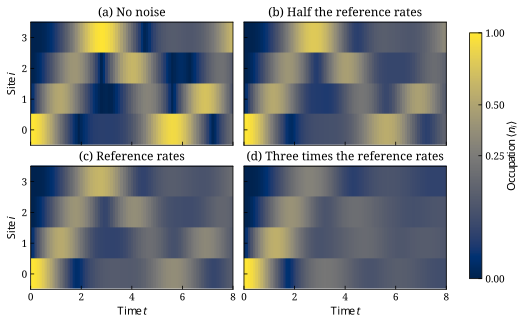

In [3]:
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("svg")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "svg.fonttype": "none",
})
occupation_norm = PowerNorm(gamma=0.5, vmin=0, vmax=1)
fig, axes = plt.subplots(2, 2, figsize=(7.2, 4.4), sharex=True, sharey=True, layout="constrained")
titles = ["(a) No noise", "(b) Half the reference rates", "(c) Reference rates", "(d) Three times the reference rates"]
for ax, scale, title in zip(axes.flat, noise_scales, titles, strict=True):
    image = ax.pcolormesh(times, np.arange(length), occupations[scale], shading="auto", cmap="cividis", norm=occupation_norm, rasterized=True)
    ax.set(title=title, yticks=np.arange(length), xlim=(0, 8))
for ax in axes[-1]:
    ax.set_xlabel(r"Time $t$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"Site $i$")
fig.colorbar(image, ax=axes, label=r"Occupation $\langle n_i\rangle$", ticks=[0, 0.25, 0.5, 1], shrink=0.92)
plt.show()

**Noise changes transport and weakens the returning excitation.** Without noise,
the excitation reflects through the chain while its total population stays one.
Relaxation removes population, and dephasing changes its spatial distribution.
Both rates change together in this comparison, so the panels show their combined
effect. We will fit the reference-rate case and use the other panels only to
illustrate the physical changes.

## 3. Select the observations and candidate channels

Assume that only the endpoints can be measured. Select rows 0 and 3 of the
synthetic $Z$ traces, keeping their time samples unchanged.

In [4]:
fitting_sites = [0, 3]
fitting_observables = [observables[site] for site in fitting_sites]
reference_z = np.asarray(reference_runs[1.0].expectation_values)
measured_z = reference_z[fitting_sites]

print("Observation shape:", measured_z.shape)

Observation shape: (2, 81)


`ref_expectations` must have shape `(n_observables, n_times)`. Here it is
`(2, 81)`: rows follow `fitting_observables`, and columns follow `params.times`,
including $t=0$. We fit $Z$ expectations, not occupations; convert measured
occupations with `measured_z = 1 - 2 * measured_occupations` when necessary.
Data from another time grid must first be aligned with the simulation grid.

The candidate model specifies which channels exist and where they act. The
optimizer will change their strengths only. We start both rates at 0.2 and allow
each to range from zero to one.

In [5]:
initial_guess = NoiseModel([
    {"name": "lowering", "sites": [3], "strength": 0.2},
    {"name": "pauli_z", "sites": [2], "strength": 0.2},
])
lower_bounds = np.zeros(2)
upper_bounds = np.ones(2)

Bounds and fitted parameters follow the order of `initial_guess.processes`:
relaxation first, dephasing second. These bounds restrict the search; they are
not uncertainty intervals. The fit assumes the Hamiltonian, initial state,
channel types, and channel locations are known. It does not discover an
arbitrary noise model from the observations.

## 4. Fit the rates

`NoiseCharacterizer` repeatedly simulates candidate models and minimizes the
mean-squared difference from the supplied traces. Its default backend selection
uses deterministic Lindblad evolution for this four-spin problem.

In [6]:
characterizer = NoiseCharacterizer(show_progress=False)
fit = characterizer.characterize(
    hamiltonian,
    params,
    init_state=state,
    init_guess=initial_guess,
    observables=fitting_observables,
    ref_expectations=measured_z,
    x_low=lower_bounds,
    x_up=upper_bounds,
    max_iter=40,
    seed=7,
)

print(f"Endpoint Z-trace RMSE: {fit.sqrt_loss_before():.4f} → {fit.trajectory_rmse():.2e}")
for name, rate in zip(("Relaxation", "Dephasing"), fit.best_parameters, strict=True):
    print(f"{name} rate: {rate:.4f}")

Endpoint Z-trace RMSE: 0.0686 → 1.10e-04
Relaxation rate: 0.3499
Dephasing rate: 0.1199


With two free parameters, YAQS uses the derivative-free CMA-ES optimizer.
`max_iter=40` limits its generations, and `seed` fixes the optimizer's random
search. This seed is separate from `AnalogSimParams.random_seed`, which controls
stochastic simulation. `NoiseCharacterizer` defaults to in-process execution;
set `parallel=True` to parallelize trajectories for vector or MPS forward
models.

For observations $z_{o,t}$, the fitted objective is

$$
J=\frac{1}{N_{\mathrm{obs}}N_t}\sum_{o,t}
\left(z_{o,t}^{\mathrm{model}}-z_{o,t}^{\mathrm{data}}\right)^2.
$$

`sqrt_loss_before()` reports the initial model's RMSE. `trajectory_rmse()`
reports the mismatch of the final fitted traces. `best_parameters` gives the
rates in process order, and `optimal_model` is the fitted `NoiseModel` ready for
simulation. The known synthetic rates let us check recovery, but a low training
error alone does not establish unique parameters.

## 5. Predict the unmeasured interior

Rerun the fitted model with all four observables. Sites 1 and 2 were withheld
from the optimization, so they test predictions beyond the fitted traces.

In [7]:
reconstructed = simulator.run(state, hamiltonian, params, fit.optimal_model)
fitted_z = np.asarray(reconstructed.expectation_values)
fitted_occupation = (1 - fitted_z) / 2
heldout_sites = [1, 2]
heldout_rmse = np.sqrt(np.mean((fitted_z[heldout_sites] - reference_z[heldout_sites]) ** 2))

print(f"Withheld interior Z-trace RMSE: {heldout_rmse:.2e}")

Withheld interior Z-trace RMSE: 7.10e-05


Compare the full dynamics on the same color scale, then inspect the withheld
sites as time traces. Reference markers are spaced out for readability; all 81
samples enter the error calculation.

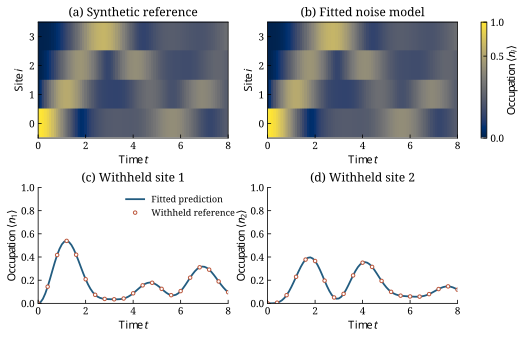

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(7.2, 4.6), layout="constrained")
for ax, dynamics, title in zip(
    axes[0],
    (occupations[1.0], fitted_occupation),
    ("(a) Synthetic reference", "(b) Fitted noise model"),
    strict=True,
):
    image = ax.pcolormesh(times, np.arange(length), dynamics, shading="auto", cmap="cividis", norm=occupation_norm, rasterized=True)
    ax.set(title=title, xlabel=r"Time $t$", ylabel=r"Site $i$", yticks=np.arange(length), xlim=(0, 8))
fig.colorbar(image, ax=list(axes[0]), label=r"Occupation $\langle n_i\rangle$", ticks=[0, 0.5, 1])
for ax, site, label in zip(axes[1], heldout_sites, ("(c)", "(d)"), strict=True):
    ax.plot(times, fitted_occupation[site], color="#225c80", lw=1.8, label="Fitted prediction")
    ax.plot(times[::4], occupations[1.0][site, ::4], "o", color="#bb563b", ms=3.5, markerfacecolor="white", label="Withheld reference")
    ax.set(title=f"{label} Withheld site {site}", xlabel=r"Time $t$", ylabel=rf"Occupation $\langle n_{site}\rangle$", xlim=(0, 8), ylim=(0, 1))
    ax.spines[["top", "right"]].set_visible(False)
axes[1, 0].legend(frameon=False, fontsize=9, loc="upper right")
plt.show()

**Endpoint observations recover the transport through the interior in this
model.** The fitted heatmap reproduces the reference, including both withheld
sites. This supports the fitted model for the specified Hamiltonian, initial
state, and observation window. It does not certify the assumed channels or
establish accuracy for other preparations, controls, or longer times. In
experimental work, reserve independent measurements for this validation step.

## Using measured data

Replace `measured_z` with your measured expectation array and keep the same
observable and time ordering. Supply exactly one of `ref_expectations` and
`reference_model`. The latter generates reference traces internally and is a
shortcut for synthetic benchmarks; it is not needed when measurements are
already available.

The example contains no measurement noise. Finite-shot data add uncertainty, and
calibration drift or an incorrect Hamiltonian can also affect the fit. The
current objective weights every observable and time sample equally; it does not
accept per-sample uncertainty weights or return confidence intervals for the
rates. Check residuals against measurement uncertainty and test withheld data
before interpreting small differences between fitted parameters.

Sparse observations can leave several rate combinations indistinguishable. Use
more times, observables, or preparations to test identifiability. A successful
optimization shows that a candidate model fits the chosen data; it does not
prove that this model is unique or that the environment has no memory. For
memory-sensitive probing, see {doc}`characterization`.

## Further options

### Forward models and sampling

`NoiseCharacterizer(representation="auto")` uses density matrices up to eight
qubits, vectors up to ten, and MPS above that size by default. Choose
`"density_matrix"`, `"vector"`, or `"mps"` explicitly when needed. See
{doc}`representation_comparison` for the numerical trade-offs.

Vector and MPS fits use trajectory-averaged MCWF and TJM simulations.
`sim_params.num_traj` controls their sampling budget; increasing it reduces
sampling error at greater cost. Refine the time step and numerical tolerances as
well as the trajectory count. A fixed `random_seed` makes the forward runs
repeatable but does not remove their sampling error. Recheck the fitted model
with more trajectories and independent seeds before drawing conclusions. For a
small system, deterministic fitting can also use stochastic or measured
reference data without making the candidate simulations stochastic.

### Optimizer controls and results

`sigma0` sets the initial CMA-ES search scale, and `popsize` sets the number of
candidates per generation. A larger search budget or several starting points can
help assess sensitivity to initialization. When there is only one free parameter
with finite bounds, YAQS uses a bounded scalar search; `max_iter` then limits
search evaluations rather than CMA-ES generations. Initial-model and final
fitted-trajectory evaluations are outside either limit.

`fit.ref_traj`, `fit.fit_traj`, and `fit.times` retain the fitted-observable
comparison. `fit.loss_history` stores candidate losses; it excludes the initial
model's separately evaluated baseline. `fit.best_loss` is the best search
objective, while `fit.sqrt_loss_after()` gives its square root. On stochastic
backends, the final rerun can differ from the best sampled objective. Inspect
the traces as well as the optimizer's reported loss.

See {class}`~mqt.yaqs.NoiseCharacterizer` for the full interface and
{doc}`realistic_noise_models` for supported one-site and two-site jump
processes.